# SD063: Vessel mounted Accoustic Doppler Current Profiler (VMADCP)

## Load required modules

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from VMADCP_section_names import dict_sections
import math
import netCDF4
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import geopandas as gpd
import re
import pandas as pd
from matplotlib.patches import Patch

## User settings

In [22]:
"""Requires either section name as defined in VMADCP_section_names.py"""
section_name = None

"""Or time window (then set section_name to None)"""
# Time window (inclusive). Use ISO strings or leave "" 
# to use the dataset range.
# Examples: "2012-06-02", "2012-06-02 12:00", "2012-06-03T18:30"
start_time = '2026-08-15 23:25:00'
end_time = '2026-08-16 08:00:00'
# end_time = '2026-08-04 20:50:00'
# 'os150nb', 'os150bb' (shallower), 'os75nb' or 'os75bb' (deeper)
adcp = 'os150bb'
# Bin size in meters for binning along ship's track
bin_size = 10
# Maximum depth to plot (None = all)
max_depth_plot = 250    # e.g. 500

if section_name is not None:
    start_time = dict_sections[section_name]['start_time']
    end_time = dict_sections[section_name]['end_time']
    adcp = dict_sections[section_name]['adcp']
    bin_size = dict_sections[section_name]['bin_size']
    max_depth_plot = dict_sections[section_name]['max_depth_plot']

system = 'mac'
if system == 'mac':
    path_server = (
        "/volumes/leg/system/adcp_teledyne_ocean_surveyor/" +
        "acquisition/uhdas/data/SD063_part2/proc/")
elif system == 'windows':
    path_server = ( 
        "system\\adcp_teledyne_ocean_surveyor\\" +
        "acquisition\\uhdas\\data\\SD063_part2\\proc\\")
nc_path = Path(f"/{path_server}{adcp}/contour/{adcp}.nc")

# Load csv file of CTD logsheet
if system == 'mac':
    CTD_file = (
        "/volumes/leg/work/scientific_work_areas/oceanography/" +
        "CTD_deployments_latest.csv")

# Load csv file of tidal amplitude
if system == 'mac':
    tide_file = (
        "/volumes/leg/work/scientific_work_areas/oceanography/" +
        "CTD/Tide_phase_fjordall.csv")

# Greenland coastlines for plotting maps
if system == 'mac':
    boundary_file = (
        "/volumes/leg/work/scientific_work_areas/gis/" +
        "Greenland_coastlines_2017/bas_greenland_coastlines.gpkg")
elif system == 'windows':
    boundary_file = ( 
        "L:\\work\\scientific_work_areas\\gis\\" +
        "Greenland_coastlines_2017\\bas_greenland_coastlines.gpkg")
    
# Save figures
if system == 'mac':
    path_plots = (
        "/volumes/leg/work/scientific_work_areas/oceanography/" +
        "VMADCP/Plots_sections/")
elif system == 'windows':
    boundary_file = ( 
        "L:\\work\\scientific_work_areas\\oceanography\\" +
        "VMADCP\\Plots_sections\\")

save_figs = True
dpi = 300                   # high-DPI PNG
also_save_pdf = False        # vector copy for print

## Load data

In [23]:
ds = xr.open_dataset(nc_path, decode_cf=True)

def clean(da):
    # replace missing value with NaN
    mv = da.attrs.get("missing_value", None)
    if mv is not None:
        da = da.where(da != mv)
    da = da.where(np.abs(da) < 1e37)
    return da

# check if requested variables are in dataset and replace missing
# value with NaN
for v in ["u", "v", "depth", "uship", "vship", "lon", "lat", "pg"]:
    if v not in ds:
        raise KeyError(f"Variable '{v}' not found in dataset")
    ds[v] = clean(ds[v])

# specific cleanup for variable "Percent Good" (pg)
ds['pg'] = ds.pg.where(ds.pg >= 0)

In [24]:
# Load locations of CTDs on this sections to plot on map
df_CTD = pd.read_csv(CTD_file)
df_CTD = df_CTD.rename(
    columns={' CTD cast number(Built In - String)': 'CTD_cast',
             ' Latitude (dd)(sd_gnss_kongsberg_seapath_320_port1_ingga - latitude)': 'lat',
             ' Longitude (dd)(sd_gnss_kongsberg_seapath_320_port1_ingga - longitude)': 'lon',
             ' Event action(Built In - String)': 'action'})
df_CTD["Time"] = pd.to_datetime(df_CTD["Time"], format="%H:%M:%S %d/%m/%Y")
df_CTD = df_CTD[(df_CTD['Time'] >= pd.Timestamp(start_time)) &
    (df_CTD['Time'] <= pd.Timestamp(end_time)) &
    (df_CTD['action'] == 'inWater')]

In [25]:
# Load tidal amplitude
df_tide = pd.read_csv(tide_file)
df_tide["Time"] = pd.to_datetime(df_tide["Time"], format="%d-%b-%Y %H:%M:%S")
df_tide = df_tide[(df_tide['Time'] >= pd.Timestamp(start_time)) &
    (df_tide['Time'] <= pd.Timestamp(end_time))]
df_tide = df_tide.set_index('Time')
tide_phase = ['high', 'falling', 'low', 'rising']
tide_col = ["palevioletred", "mediumaquamarine", "seagreen", "pink"]

## Select time

In [26]:
def parse_time(s):
    return None if (not s or s.strip() == "") else np.datetime64(s)

t0 = parse_time(start_time) or ds.time.min().values
t1 = parse_time(end_time)   or ds.time.max().values
ds = ds.sel(time=slice(t0, t1))
if ds.sizes.get("time", 0) < 2:
    raise ValueError("No (or insufficient) data in selected time window")

In [27]:
if section_name == 'hovmoeller double trough 16.08.':
    # cut out brief trip back to icefront
    ds = ds.where((ds.time < ds.time[43]) | (ds.time > ds.time[60]))

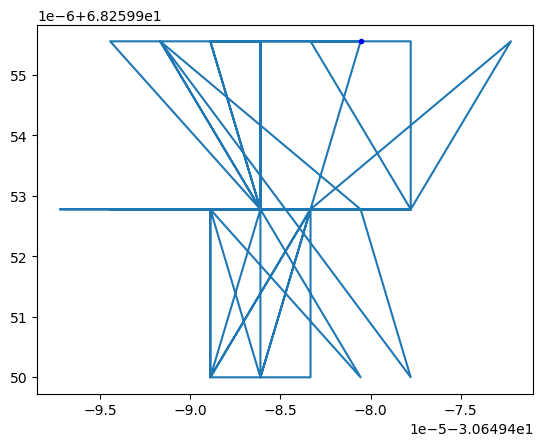

In [28]:
plt.plot(ds.lon, ds.lat)
plt.plot(ds.lon[0], ds.lat[0], '.b')

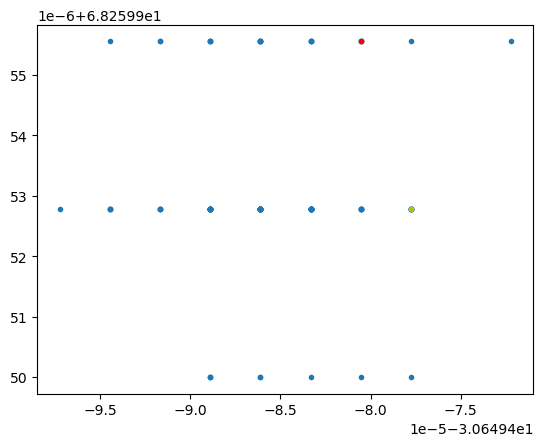

In [29]:
plt.plot(ds.lon, ds.lat, '.')
plt.plot(ds.lon[0], ds.lat[0], '.r')
plt.plot(ds.lon[-1], ds.lat[-1], '.y')

## Reorder dataset

First datapoint should have the most southern latitude.
If not, reverse direction of time dimension.

In [30]:
if section_name is not None and section_name[:10] == 'hovmoeller':
    print('')
elif ds.lat[0] > ds.lat[-1]:
    ds = ds.sortby('time', ascending=False)
    print('Reversed direction of time dimension -> ' +
          'now dataset starts with most southern latitude')

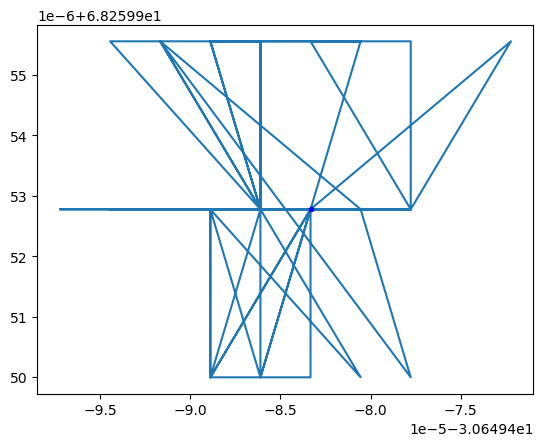

In [31]:
plt.plot(ds.lon, ds.lat)
plt.plot(ds.lon[26], ds.lat[26], '.b')

## Rotate u and v from VMADCP into along- and across-track velocity using ship's heading

In [32]:
def calculate_bearing(lat1, lon1, lat2, lon2):
    # Ensure point 1 is the southern point
    if lat1 > lat2:
        lat1, lat2 = lat2, lat1
        lon1, lon2 = lon2, lon1

    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)

    dlon = lon2 - lon1

    x = np.sin(dlon) * np.cos(lat2)
    y = (np.cos(lat1) * np.sin(lat2) -
         np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

In [33]:
# bearing of section in degrees calculated between first and last
# point of the section and re-ordered such that the section heading
# is from south → north
if section_name is not None and 'idx_bend' in dict_sections[section_name]:
    idx_bend = dict_sections[section_name]['idx_bend']
    bearing1 = calculate_bearing(
        ds.lat[0].values, ds.lon[0].values,
        ds.lat[idx_bend].values, ds.lon[idx_bend].values)
    print('Bearing of section to bend: ' + str(np.round(bearing1, 1)) + '°')
    bearing2 = calculate_bearing(
        ds.lat[idx_bend].values, ds.lon[idx_bend].values,
        ds.lat[-1].values, ds.lon[-1].values)
    print('Bearing of section to icefront: ' + str(np.round(bearing2, 1)) + '°')
    bearing1 = bearing1*np.ones([idx_bend])
    bearing2 = bearing2*np.ones([int(len(ds.lat)-idx_bend)])
    bearing = xr.DataArray(np.concatenate([bearing1, bearing2]), dims='time')
elif section_name is not None and section_name[:10] == 'hovmoeller':
    bearing = dict_sections[section_name]['angle']
    print('Angle across fjord: ' + str(np.round(bearing, 1)) + '°')
else:
    bearing = calculate_bearing(
        ds.lat[0].values, ds.lon[0].values,
        ds.lat[-1].values, ds.lon[-1].values)
    print('Bearing of section: ' + str(np.round(bearing, 1)) + '°')

# bearing in radians
theta = np.deg2rad(bearing)

# northerly flow is defined as positive flow along the section
along_vel = ds.u * np.sin(theta) + ds.v * np.cos(theta)
# positive across-section transport is defined to the right of the
# section direction
across_vel = ds.u * np.cos(theta) - ds.v * np.sin(theta)

# add to dataset
along_vel.attrs = {'long_name': 'Along-track velocity from VMADCP',
                   'units': 'meter second-1'}
ds['along_vel'] = along_vel
across_vel.attrs = {'long_name': 'Across-track velocity from VMADCP',
                   'units': 'meter second-1'}
ds['across_vel'] = across_vel

Angle across fjord: 35°


## Add along-track distance and index for along track binning to dataset

In [34]:
def calculate_distance(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between points specified by
    lat/lon arrays (degrees).

    Returns
    -------
    d : ndarray
        Distance(s) in metres.
    """
    radius = 6371000.0  # metres

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    )
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

    return radius * c

In [35]:
dist = calculate_distance(
    ds.lat[1:].values, ds.lon[1:].values, 
    ds.lat[:-1].values, ds.lon[:-1].values)
dist = np.cumsum(dist)
dist = np.concatenate(([0], dist))
dist = xr.DataArray(dist, dims="time")
# Write dimension attributes (units, long_name, valid data range)
dist.attrs = {
    'long_name':'cumulative distance from starting location', 
    'units':'m','valid_min':'0'}
ds['distance_along_track'] = dist

In [36]:
# index for along track binning
bin_index = np.floor(dist.values/bin_size)
ds.coords["bin_index"] = ("time", bin_index)

## Select times of tidal amplitudes for along-track binned dataset

In [37]:
time_binned = ds.time.groupby("bin_index").mean().values
df_idx = df_tide.index.get_indexer(time_binned, method='nearest')
df_tide_binned = df_tide.iloc[df_idx]
# sort time into acending order again
df_tide_binned = df_tide_binned.sort_index(ascending=True)

## Plots

In [38]:
# Load coastlines for plotting
greenland_boundary = gpd.read_file(boundary_file)
greenland_transform = greenland_boundary.to_crs("EPSG:4326")

In [39]:
def section_VMADCP(orientation='coordinates'):

    if orientation == 'coordinates':
        vel_u = ds.u.groupby('bin_index').mean()
        title_u = 'Zonal velocity (m s$^{-1}$)'
        if (section_name is not None) and (
            'vmax' in dict_sections[section_name]):
            vmax_u =  dict_sections[section_name]['vmax'][0]
        else:
            vmax_u = np.abs(vel_u).quantile(0.98)
        vel_v = ds.v.groupby("bin_index").mean()
        title_v = 'Meridional velocity (m s$^{-1}$)'
        if (section_name is not None) and (
            'vmax' in dict_sections[section_name]):
            vmax_v =  dict_sections[section_name]['vmax'][1]
        else:
            vmax_v = np.abs(vel_v).quantile(0.98)
    elif orientation == 'rotated':
        vel_u = ds.across_vel.groupby('bin_index').mean()
        title_u = 'Across-track velocity (m s$^{-1}$)'
        if (section_name is not None) and (
            'vmax' in dict_sections[section_name]):
            vmax_u =  dict_sections[section_name]['vmax'][2]
        else:
            vmax_u = np.abs(vel_u).quantile(0.98)
        vel_v = ds.along_vel.groupby("bin_index").mean()
        title_v = 'Along-track velocity (m s$^{-1}$)'
        if (section_name is not None) and (
            'vmax' in dict_sections[section_name]):
            vmax_v =  dict_sections[section_name]['vmax'][3]
        else:
            vmax_v = np.abs(vel_v).quantile(0.98)
        
    fig = plt.figure(figsize=(12, 7))
    
    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        width_ratios=[1, 3],
        height_ratios=[1, 1],
        hspace=0.33, wspace=0.15)
    
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(
        central_longitude=-31))
    ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(
        central_longitude=-31))
    ax3 = fig.add_subplot(gs[0, 1])
    ax4 = fig.add_subplot(gs[1, 1], sharex=ax3)
    
    proj = ccrs.PlateCarree()
    
    lon_binned = ds.lon.groupby("bin_index").mean()
    lat_binned = ds.lat.groupby("bin_index").mean()
    dist_binned = ds.distance_along_track.groupby(
        "bin_index").mean().values
    
    """ Map of area """
    greenland_transform.plot(ax=ax1,color='silver', transform=proj)
    ax1.scatter(lon_binned, lat_binned, s=5, c='c', transform=proj)
    if (section_name is not None) and (
        'extent_map' in dict_sections[section_name]):
            ax1.set_extent(dict_sections[section_name]['extent_map'],
                           crs=proj)
    else:
        ax1.set_extent(
            [ds.lon.min('time')-2, ds.lon.max('time')+2,
             ds.lat.min('time')-2, ds.lat.max('time')+2],
            crs=proj)
    gl = ax1.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax1.set_aspect('auto')
    if section_name is not None:
        ax1.set_title(section_name, fontweight='bold')
    
    """ Map of section """
    greenland_transform.plot(ax=ax2,color='silver', transform=proj)
    ax2.scatter(lon_binned, lat_binned, s=5, c='c', transform=proj)
    ax2.scatter(df_CTD.lon.values, df_CTD.lat.values, s=20,
                c='orange', marker='*', transform=proj)

    dlon = abs(ds.lon.max('time') - ds.lon.min('time')).values
    if dlon < 0.1:
        dlon = 0.1
    dlat = abs(ds.lat.max('time') - ds.lat.min('time')).values
    if dlat < 0.1:
        dlat = 0.1
    ax2.set_extent([ds.lon.min('time')-dlon/2, ds.lon.max('time')+dlon/2,
                    ds.lat.min('time')-dlat/2, ds.lat.max('time')+dlat/2],
                   crs=proj)
    gl = ax2.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax2.set_aspect('auto')
    
    step = 1 if np.floor(dist_binned[-1]/1000) <= 10 else 10
    dist_labels = np.arange(0, np.floor(dist_binned[-1]/1000) + step,
                            step, dtype=int)
    dist_idx = [np.abs(
        dist_binned/1000 - t).argmin()
                for t in dist_labels]
    for i in range(len(dist_idx)):
        ax2.text(lon_binned[dist_idx[i]], lat_binned[dist_idx[i]],
                 dist_labels[i], transform=proj)    
    if orientation == 'rotated':
        if bearing.size == 1:
            ax2.plot([ds.lon[0], ds.lon[-1]], [ds.lat[0], ds.lat[-1]],
                     'k--', transform=proj)
            ax2.text(
                .05, .05, 'bearing of section (--)\nfor velocity rotation: ' +
                str(np.round(bearing, 1)) + '°', transform=ax2.transAxes,
                bbox=dict(facecolor='white', boxstyle='round,pad=0.3'))
        else:
            idx = abs(bearing.diff('time')).argmax('time').values+1
            ax2.plot([ds.lon[0], ds.lon[idx], ds.lon[-1]],
                     [ds.lat[0], ds.lat[idx], ds.lat[-1]],
                     'k--', transform=proj)
            ax2.text(
                .05, .05, 'bearing of section (--) for\nvelocity rotation: ' +
                str(np.round(bearing1[0], 1)) + '°, ' +
                str(np.round(bearing2[0], 1)) + '°', transform=ax2.transAxes,
                bbox=dict(facecolor='white', boxstyle='round,pad=0.3'))

    
    """ Zonal or Across-track velocity """
    v_max = np.abs(vel_u).quantile(0.98)
    pc = ax3.pcolormesh(
        dist_binned/1000, ds.depth.mean('time'),
        vel_u.transpose(), cmap='RdBu_r', vmin=-vmax_u, vmax=vmax_u)
    ax3.set_ylim(max_depth_plot, 0)
    
    # add bar showing rising and falling tides
    ymin, ymax = ax3.get_ylim()
    height = 0.05 * (ymax - ymin)  # 5% of plot height
    for j in range(len(tide_phase)):
        ax3.fill_between(
             dist_binned/1000, ymin, ymin + height,
             where=(df_tide_binned['phase'] == tide_phase[j]),
             color=tide_col[j], step="mid")
        if j == 0:
            legend_handles = [
                Patch(facecolor=tide_col[j],
                      label=(tide_phase[j] + " tide")),]
        else: 
            legend_handles.append(
                Patch(facecolor=tide_col[j],
                      label=(tide_phase[j])))

    # add lines for CTD stations
    if not df_CTD.empty:
        ctd_lon_idx = [np.argmin(np.abs(
            lon_binned.values - t)) for t in df_CTD.lon.values]
        for i in range(len(ctd_lon_idx)):
            li = ax3.axvline(dist_binned[ctd_lon_idx[i]]/1000,
                             color='orange', label='CTD')
            ax3.text(dist_binned[ctd_lon_idx[i]]/1000, max_depth_plot-20,
                     '#' + str(df_CTD.CTD_cast.values[i]))
        legend_handles.append(li)

    ax3.legend(handles=legend_handles, loc='upper center',
               bbox_to_anchor=(0.5, -0.07), ncol=5)
        
    if (section_name is not None) and (
        dict_sections[section_name]['flip_xax'] == True):
        ax3.invert_xaxis()
    plt.colorbar(pc, extend='both')
    ax3.set_title(title_u)
    if orientation == 'rotated':
        ax3.text(
            1.005, 0.08, '  to left of              to right of\n' +
            'the section           the section',
            rotation=90, transform=ax3.transAxes)
    
    
    """ Meridional and Along-track velocity """
    v_max = np.abs(vel_v).quantile(0.98)
    pc = ax4.pcolormesh(
        dist_binned/1000, ds.depth.mean('time'),
        vel_v.transpose(), cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v)
    ax4.set_ylim(max_depth_plot, 0)
    
    # add bar showing rising and falling tides
    for j in range(len(tide_phase)):
        ax4.fill_between(
             dist_binned/1000, ymin, ymin + height,
             where=(df_tide_binned['phase'] == tide_phase[j]),
             color=tide_col[j], step="mid")
    
    # add lines for CTD stations
    if not df_CTD.empty:
        for i in range(len(ctd_lon_idx)):
            li = ax4.axvline(dist_binned[ctd_lon_idx[i]]/1000, color='orange')
            ax4.text(dist_binned[ctd_lon_idx[i]]/1000, max_depth_plot-20,
                     '#' + str(df_CTD.CTD_cast.values[i]))
        
    plt.colorbar(pc, extend='both')
    ax4.set_title(title_v)
    ax4.set_xlabel('Along-track distance (km)')
    if orientation == 'rotated':
        ax4.text(
            1.005, 0.05, '"southwards"        "northwards"\n' +
            'along section        along section',
            rotation=90, transform=ax4.transAxes)

    if save_figs:
        plt.savefig(
            path_plots + 'VMADCP_section_' +
            re.sub(r'_+', '_', re.sub(r'[ ./:]', '_', section_name)).rstrip('_') +
            '_' + orientation + '.png', dpi=dpi, bbox_inches="tight")
    plt.show()

In [40]:
def hovmoeller_VMADCP():
    fig = plt.figure(figsize=(12, 9))
    plt.subplots_adjust(hspace=.3)
    
    var_all = [ds.u, ds.v, ds.across_vel, ds.along_vel]
    title_all = ['Zonal velocity (m s$^{-1}$)',
                 'Meridional velocity (m s$^{-1}$)',
                 'Along-fjord velocity (m s$^{-1}$)',
                 'Across-fjord velocity (m s$^{-1}$)']
    
    # Time formatting
    locator = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(locator)
    
    for i, var in enumerate(var_all):
        ax = plt.subplot(4, 1, i+1)
        v_max = np.abs(var).quantile(0.98)
        plt.pcolormesh(
            ds.time, ds.depth.mean('time'), var.transpose(),
            cmap='RdBu_r', vmin=-v_max, vmax=v_max)
        plt.ylim(max_depth_plot, 0)
        plt.colorbar(extend='both', aspect=10, pad=0.03)
        plt.title(title_all[i])
        fig.supylabel('Depth (m)', fontsize=11, x=0.07)
    
        if title_all[i][:11] == 'Along-fjord':
             ax.text(
                1.008, 0, 'into fjord   out of fjord',
                rotation=90, transform=ax.transAxes)
        elif title_all[i][:12] == 'Across-fjord':
             ax.text(
                1.008, -0.2, '"southwards"    "northwards"',
                rotation=90, transform=ax.transAxes)

        # add bar showing rising and falling tides
        ymin, ymax = ax.get_ylim()
        height = 0.05 * (ymax - ymin)  # 5% of plot height
        for j in range(len(tide_phase)):
            ax.fill_between(
                df_tide.index, ymin, ymin + height,
                where=(df_tide['phase'] == tide_phase[j]),
                color=tide_col[j], step="mid")
            if i == 0:
                if j == 0:
                    legend_handles = [
                        Patch(facecolor=tide_col[j],
                              label=(tide_phase[j] + " tide")),]
                else: 
                    legend_handles.append(
                        Patch(facecolor=tide_col[j],
                              label=(tide_phase[j])))

        # add lines for CTD stations
        
        if not df_CTD.empty:
            for k in range(len(df_CTD)):
                li = ax.axvline(df_CTD['Time'].values[k],
                                color='orange', label='CTD')
                ax.text(df_CTD['Time'].values[k], max_depth_plot-20,
                        '#' + str(df_CTD.CTD_cast.values[k]))
                if (i == 0) and (k == 0):
                    legend_handles.append(li)

        ax.xaxis.set_major_locator(locator)
        ax.set_xticklabels([])
        ax.set_xlim(np.datetime64(t0), np.datetime64(t1))
        if i == (len(var_all)-1):
            ax.xaxis.set_major_formatter(fmt)
            ax.legend(handles=legend_handles, loc='upper center',
                      bbox_to_anchor=(0.5, -0.14), ncol=5)
        if (section_name is not None) and (i == 0):
             plt.text(-.07, 1.1, section_name[11:], fontweight='bold',
                      fontsize=12, transform=ax.transAxes)

    if save_figs:
        plt.savefig(
            path_plots + 'VMADCP_' +
            re.sub(r'_+', '_', re.sub(r'[ ./:]', '_', section_name)).rstrip('_') +
            '.png', dpi=dpi, bbox_inches="tight")

    plt.show()

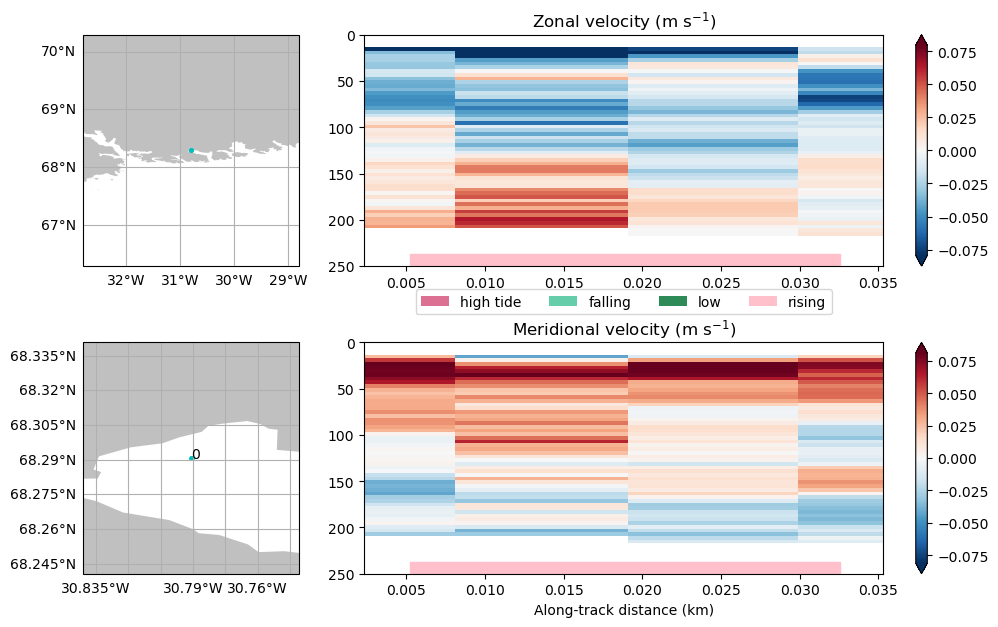

In [131]:
section_VMADCP(orientation='coordinates')

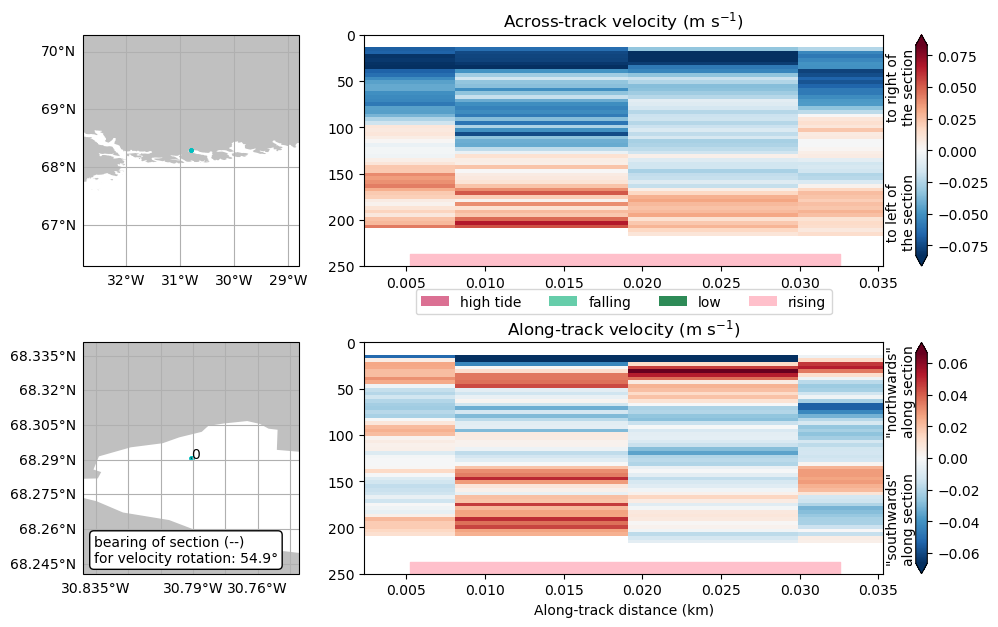

In [132]:
section_VMADCP(orientation='rotated')

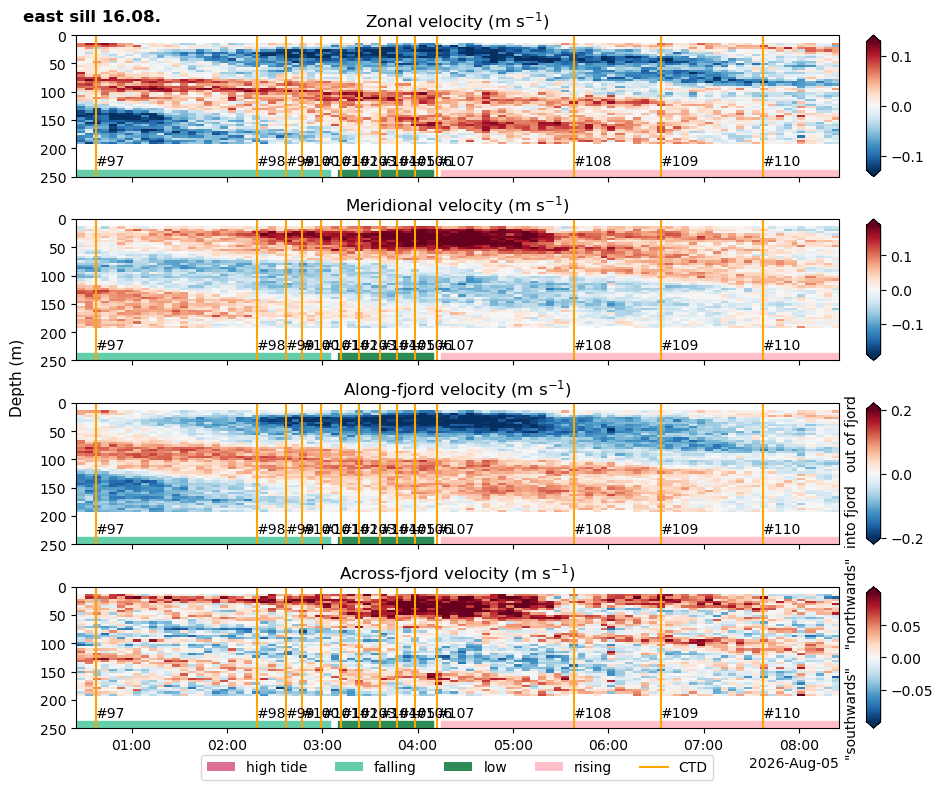

In [41]:
hovmoeller_VMADCP()